In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("shop_smart_ecommerce.csv")
# df.head()
# df.info()
# df.isnull().sum()

In [3]:
X = df.drop("Revenue",axis=1)
y = df["Revenue"].astype("int64")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
num_features = X.select_dtypes(include="number").columns
catg_features = X.select_dtypes(include=["object", "category"]).columns

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num_steps", StandardScaler(), num_features),
        ("catg_steps", OneHotEncoder(), catg_features)
    ]
)

In [6]:
model = DecisionTreeClassifier(random_state=42)

In [7]:
pipe = Pipeline(
    steps=[
        ("Preprocess", preprocessor),
        ("model", model)
    ]
)

In [8]:
pipe.fit(X_train, y_train)

,steps,"[('Preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_steps', ...), ('catg_steps', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [9]:
y_pred = pipe.predict(X_test)

# Evaluation

In [10]:
print("F1 score : ", f1_score(y_test,y_pred))
print("Confusion Matrix : \n", confusion_matrix(y_test,y_pred))
print("Classification Report : \n", classification_report(y_test,y_pred))

F1 score :  0.5454545454545454
Confusion Matrix : 
 [[1914  170]
 [ 175  207]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.92      0.92      0.92      2084
           1       0.55      0.54      0.55       382

    accuracy                           0.86      2466
   macro avg       0.73      0.73      0.73      2466
weighted avg       0.86      0.86      0.86      2466



### Key Insight: Decoding F1-Score

* **`f1_score()` Default:** Focuses only on **Class 1 (Buyers)**, which is why it outputted `0.55`.
* **Report vs Metric:** `classification_report` shows both classes + `weighted avg` (`0.86`). To get this overall score in code, use: `f1_score(y_test, y_pred, average='weighted')`.
* **Imbalance & Overfitting:** **Class 0** dominates (2,084 samples) leading to a high score (`0.92`). **Class 1** struggles at `0.55` because the default tree overfits the training data (Training F1 is 1.0).

# Model Score for Training Data -> Overfitting

In [11]:
y_train_pred = pipe.predict(X_train)
print("Training F1 score : ", f1_score(y_train,y_train_pred))

Training F1 score :  1.0


# Hyperparameter Tuning

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [4, 5, 6, 8],
    "model__min_samples_split": [40, 150, 200],
    "model__min_samples_leaf": [30, 50, 80]
}

grid = GridSearchCV(pipe, param_grid, scoring="f1", cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best CV F1 Score:", grid.best_score_)
print("Best Params found:", grid.best_params_)

best_model = grid.best_estimator_
y_grid_pred = best_model.predict(X_test)
print("\nActual Test F1 Score:", f1_score(y_test, y_grid_pred))

Best CV F1 Score: 0.6599762137086971
Best Params found: {'model__criterion': 'entropy', 'model__max_depth': 6, 'model__min_samples_leaf': 30, 'model__min_samples_split': 200}

Actual Test F1 Score: 0.5984251968503937


# Pre-Pruning (To Overcome Overfitting)

In [13]:
# Pre Pruning
model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=150,
    min_samples_leaf=80,
    criterion='entropy', 
    random_state=42
)
pipe = Pipeline(
    steps=[
        ("Preprocess", preprocessor),
        ("model", model)
    ]
)
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print("----------------- After Pre Pruning ----------------- ")
print("F1 score : ", f1_score(y_test,y_pred))
print("Confusion Matrix : \n", confusion_matrix(y_test,y_pred))
print("Classification Report : \n", classification_report(y_test,y_pred))

----------------- After Pre Pruning ----------------- 
F1 score :  0.6629213483146067
Confusion Matrix : 
 [[1990   94]
 [ 146  236]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.93      0.95      0.94      2084
           1       0.72      0.62      0.66       382

    accuracy                           0.90      2466
   macro avg       0.82      0.79      0.80      2466
weighted avg       0.90      0.90      0.90      2466



# Tree Structure Visualization
The tree has been plotted below to visualize the splitting logic and feature importance down to a maximum depth of 5.

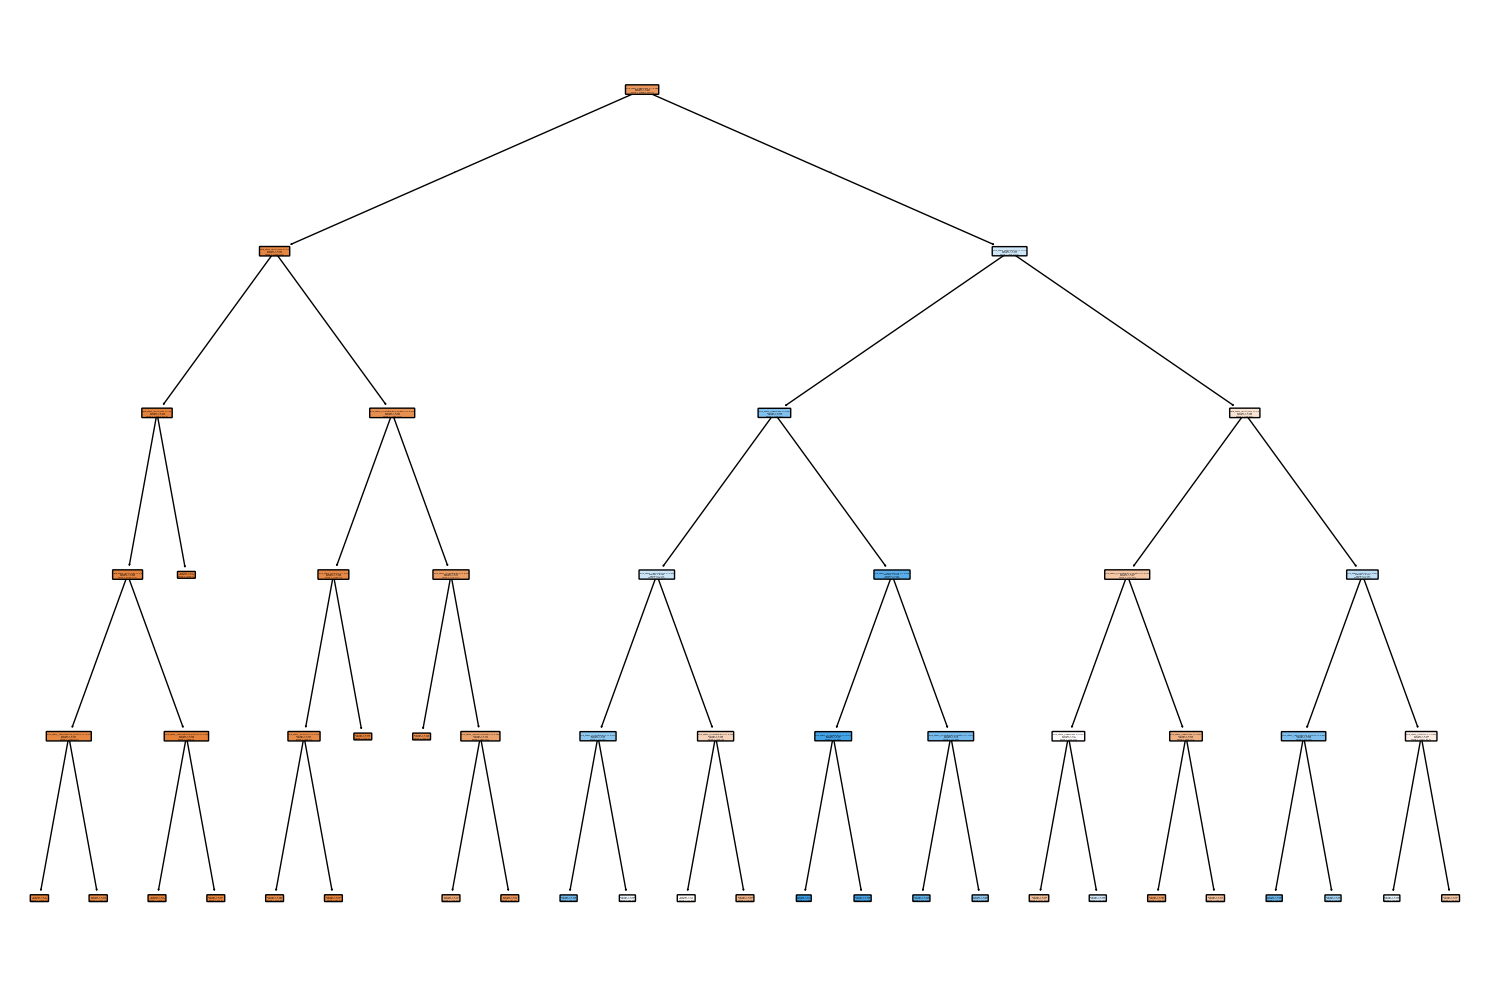

In [14]:
plt.figure(figsize=(15,10))
plot_tree(
    pipe.named_steps["model"],
    feature_names=pipe.named_steps["Preprocess"].get_feature_names_out(),
    class_names=["Not Buyer","Buyer"],
    filled=True,
    rounded=True
)

plt.tight_layout()
plt.show()

## Model Performence for training data after pre pruning

In [15]:
y_train_pred = pipe.predict(X_train)
print("Training F1 score : ", f1_score(y_train,y_train_pred))
print("Confusion Matrix : \n", confusion_matrix(y_train,y_train_pred))
print("Classification Report : \n", classification_report(y_train,y_train_pred))

Training F1 score :  0.681210415200563
Confusion Matrix : 
 [[7990  348]
 [ 558  968]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.93      0.96      0.95      8338
           1       0.74      0.63      0.68      1526

    accuracy                           0.91      9864
   macro avg       0.84      0.80      0.81      9864
weighted avg       0.90      0.91      0.91      9864



# Decision Tree Model Evaluation
The Decision Tree model has been fully optimized using pre-pruning techniques. The training and testing scores are completely balanced, indicating excellent model generalization.

Key Insights:
No Overfitting:

Training F1-Score: 0.6812
Test F1-Score: 0.6629
The minimal gap between the two scores proves that the model generalizes effectively to unseen data without memorizing the training set.
Class 1 (Buyers) Performance:

Precision: 72%
This indicates that when a positive purchase prediction is made, the reliability of that prediction is high.